# Hotel Revenue & Occupancy Analysis

## Business question
How did realized revenue and weighted occupancy vary by city, booking calendar, and hotel segment from May to July 2022?

**Scope:** 134,590 booking-level records, 9,200 aggregate occupancy records, 25 properties, 4 cities, and 4 room categories.

> **Data note:** The original source files are intentionally excluded from this public repository. This notebook retains the analysis logic and validated outputs for portfolio review.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("datasets")  # Source data is excluded from this public repository


## 1. Load and profile the source tables

In [2]:
bookings = pd.read_csv(DATA_DIR / "fact_bookings.csv")
aggregate_bookings = pd.read_csv(DATA_DIR / "fact_aggregated_bookings.csv")
hotels = pd.read_csv(DATA_DIR / "dim_hotels.csv")
rooms = pd.read_csv(DATA_DIR / "dim_rooms.csv")
calendar = pd.read_csv(DATA_DIR / "dim_date.csv")

print(f"Booking records: {len(bookings):,}")
print(f"Aggregate occupancy records: {len(aggregate_bookings):,}")
print(f"Properties: {hotels['property_id'].nunique()} | Cities: {hotels['city'].nunique()} | Room categories: {rooms['room_id'].nunique()}")

Booking records: 134,590
Aggregate occupancy records: 9,200
Properties: 25 | Cities: 4 | Room categories: 4


## 2. Clean and validate booking data

Invalid guest counts and extreme generated-revenue records are excluded. Missing ratings are retained because a missing rating is not evidence of a failed booking.

In [3]:
# Remove invalid guest counts
bookings = bookings.loc[bookings['no_guests'] > 0].copy()

# Identify and remove extreme generated-revenue records using a 3σ rule
revenue_limit = bookings['revenue_generated'].mean() + 3 * bookings['revenue_generated'].std()
bookings = bookings.loc[bookings['revenue_generated'] <= revenue_limit].copy()

# Confirm values used in financial analysis are finite
assert np.isfinite(bookings['revenue_realized']).all()

print(f"Cleaned booking records: {len(bookings):,}")
print(f"Missing ratings retained: {bookings['ratings_given'].isna().sum():,}")

Cleaned booking records: 134,573
Missing ratings retained: 77,897


## 3. Standardize dates and enrich bookings

Dates are parsed explicitly with day-first handling. The many-to-one validation protects the analysis against accidental row multiplication during dimension joins.

In [4]:
bookings['check_in_date'] = pd.to_datetime(bookings['check_in_date'], format='mixed', dayfirst=True)
calendar['date'] = pd.to_datetime(calendar['date'], format='%d-%b-%y')
calendar['day_type'] = calendar['day_type'].replace({'weekeday': 'weekday'})

bookings_enriched = bookings.merge(hotels, on='property_id', validate='many_to_one')
bookings_enriched = bookings_enriched.merge(
    calendar, left_on='check_in_date', right_on='date', validate='many_to_one'
)
assert len(bookings_enriched) == len(bookings)
print(f"Rows retained after dimension joins: {len(bookings_enriched):,}")

Rows retained after dimension joins: 134,573


## 4. Calculate weighted occupancy

Occupancy is calculated from total successful bookings divided by total available capacity—not by averaging pre-calculated percentages.

In [5]:
# Impute missing capacity within the same property and room category
aggregate_bookings['capacity'] = aggregate_bookings['capacity'].fillna(
    aggregate_bookings.groupby(['property_id', 'room_category'])['capacity'].transform('median')
)

# Exclude records with impossible capacity relationships
aggregate_bookings = aggregate_bookings.loc[
    aggregate_bookings['successful_bookings'] <= aggregate_bookings['capacity']
].copy()

def weighted_occupancy(frame):
    return 100 * frame['successful_bookings'].sum() / frame['capacity'].sum()

aggregate_bookings['check_in_date'] = pd.to_datetime(
    aggregate_bookings['check_in_date'], format='%d-%b-%y'
)
occupancy = aggregate_bookings.merge(rooms, left_on='room_category', right_on='room_id', validate='many_to_one')
occupancy = occupancy.merge(hotels, on='property_id', validate='many_to_one')
occupancy = occupancy.merge(calendar, left_on='check_in_date', right_on='date', validate='many_to_one')

city_occupancy = occupancy.groupby('city').apply(weighted_occupancy, include_groups=False).sort_values(ascending=False)

print(f"Invalid capacity records excluded: {9200 - len(aggregate_bookings):,}")
print(city_occupancy.round(2).rename('weighted_occupancy_pct'))

Invalid capacity records excluded: 6
city
Delhi        60.52
Hyderabad    58.07
Mumbai       57.88
Bangalore    55.76
Name: weighted_occupancy_pct, dtype: float64


## 5. Revenue performance by city

In [6]:
city_revenue = (
    bookings_enriched.groupby('city')['revenue_realized']
    .sum()
    .sort_values(ascending=False)
)
print((city_revenue / 1_000_000).round(1).rename('realized_revenue_inr_millions'))

city
Mumbai       668.6
Bangalore    420.4
Hyderabad    325.2
Delhi        294.4
Name: realized_revenue_inr_millions, dtype: float64


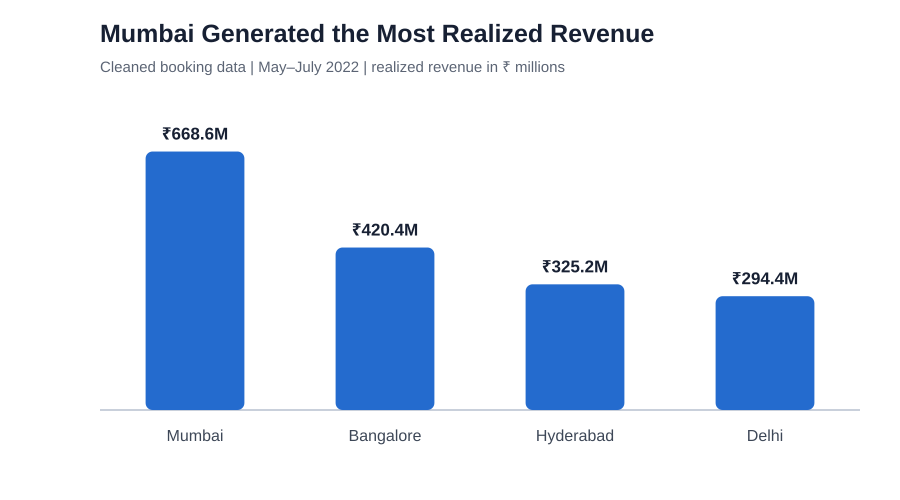

In [7]:
ax = (city_revenue / 1_000_000).sort_values().plot.barh(color='#246BCE', figsize=(10, 5))
ax.set(title='Mumbai Generated the Most Realized Revenue', xlabel='Realized revenue (₹ millions)', ylabel='City')
plt.tight_layout()

## 6. Occupancy by calendar type

In [8]:
day_type_occupancy = occupancy.groupby('day_type').apply(weighted_occupancy, include_groups=False).sort_values(ascending=False)
print(day_type_occupancy.round(2).rename('weighted_occupancy_pct'))

day_type
weekend    73.59
weekday    51.34
Name: weighted_occupancy_pct, dtype: float64


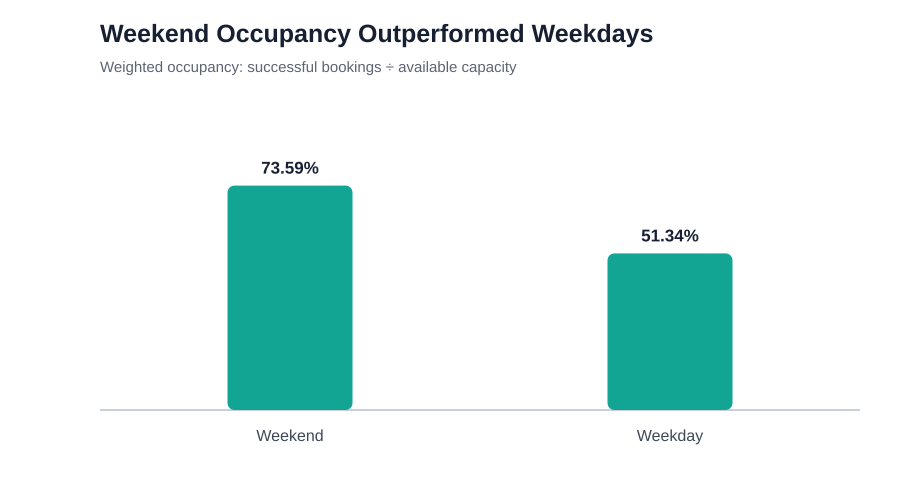

In [9]:
ax = day_type_occupancy.reindex(['weekend', 'weekday']).plot.bar(color='#12A594', figsize=(8, 5), ylim=(0, 100))
ax.set(title='Weekend Occupancy Outperformed Weekdays', xlabel='', ylabel='Weighted occupancy (%)')
plt.tight_layout()

## Key findings

1. **Mumbai generated the most realized revenue** at approximately **₹668.6M**, over twice Delhi's revenue.
2. **Weekend weighted occupancy was 73.59%**, versus **51.34%** on weekdays—a gap of **22.25 percentage points**.
3. **Delhi had the highest weighted occupancy** among cities at **60.52%**, suggesting a potential opportunity to examine pricing, room mix, or channel strategy alongside revenue.
4. The figures cover **May–July 2022** only and should be treated as descriptive analysis, not causal evidence.

## Reproducibility note

The code uses relative `datasets/` paths, but the original data is not published. Cached outputs and chart renders are preserved so reviewers can inspect the analysis approach without access to the source files.